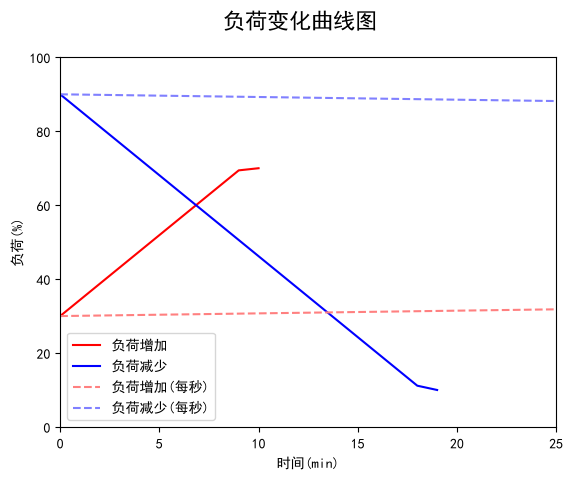

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ramp_load(start, end, dt, rate=4.38):
    t_data = []
    t_load, t= start, 0
    if rate > 0:
        while t_load < end:
            t_data.append([t, t_load])
            t = t + dt
            t_load = t_load + rate * dt
            if t_load > end:
                t_load = end
                t_data.append([t, t_load])
                break
        return np.array(t_data)
    elif rate < 0:
        while t_load > end:
            t_data.append([t, t_load])
            t = t + dt
            t_load = t_load + rate * dt
            if t_load < end:
                t_load = end
                t_data.append([t, t_load])
                break
        return np.array(t_data)

data_inc = ramp_load(30, 70, 1)
load_increase = pd.DataFrame({'时间': data_inc[:,0], '负荷': data_inc[:,1]})
data_dec = ramp_load(90, 10, 1, -4.38)
load_decrease = pd.DataFrame({'时间': data_dec[:,0], '负荷': data_dec[:,1]})
data_inc_persec = ramp_load(30, 70, 1, 0.073)
load_increase_persec = pd.DataFrame({'时间': data_inc_persec[:,0], '负荷': data_inc_persec[:,1]})
data_dec_persec = ramp_load(90, 10, 1, -0.073)
load_decrease_persec = pd.DataFrame({'时间': data_dec_persec[:,0], '负荷': data_dec_persec[:,1]})

fig, ax = plt.subplots()
fig.suptitle('负荷变化曲线图', fontsize=16)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 将字体设置为黑体
plt.rcParams['axes.unicode_minus'] = False    # 依然要保留这句，防止负号显示异常
ax.set_xlim(0, 25)
ax.set_ylim(0, 100)
ax.set_xlabel("时间(min)")
ax.set_ylabel("负荷(%)")
labels = ['负荷增加', '负荷减少', '负荷增加(每秒)', '负荷减少(每秒)']
linestyles = ['-', '-', '--', '--']
colors = ['#ff0000','#0000ff', '#ff8080', "#8080ff"]
for (i, k) in enumerate([load_increase, load_decrease, load_increase_persec, load_decrease_persec]):
    ax.plot(k['时间'], k['负荷'], color = colors[i], linestyle = linestyles[i], label=labels[i])
ax.legend(loc='best')

Q1：步长 1s 和 1min 结果差多少？

宏观结果：总耗时和最终到达的负荷值几乎完全一致（比如 30% 升到 70%，都是约 9.13 分钟）。

计算代价：1min 步长只需循环约 10 次，计算量极小；1s 步长需要循环约 540 次，计算量增大。

曲线精度：1min 步长画出来的是有明显折角的“阶梯状”折线；1s 步长画出来的是极其平滑的曲线。在实际工程中，如果是做分钟级的 RTO 优化，1min 步长足够；如果是底层 DCS 安全联锁控制，就必须用 1s 甚至更短的步长来捕捉瞬态波动。

Q2：如果速率限制和上下限冲突，应该优先保哪个？

答案：绝对优先保上下限（安全边界）。

原因：化工生产“安全大于天”。如果负荷已经达到 110%（设备极限），即便速率要求你继续升，也必须强行截断在 110%（即代码里的 t_load = 110; break），否则会引发超压爆炸；同理，降到 10% 必须停住，否则会导致催化剂中毒或停产。速率约束是为了保护设备寿命，而上下限约束是为了保命。

Q3：实际化工装置为什么不能瞬间跳变？

物理与机械原因：瞬间大幅调整负荷会产生巨大的热应力，导致设备金属疲劳开裂；压缩机、汽轮机等转动设备有机械惯性，瞬间变速会导致喘振甚至损坏。

化学原因：合成氨依赖催化剂，温度、压力的骤变会导致催化剂活性受损、副反应加剧甚至“飞温”。

流体力学原因：管道内流体的流动、阀门的响应都有物理延迟，不可能瞬间完成流量的大幅切换。